# Shiptivity Data Visualisations

Analyzing daily login counts and status changes before and after the Kanban Board feature release on June 2, 2018.

In [1]:
# Import Required Libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Connect to the Database
db_path = 'shiptivity.db'
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

print(f"Connected to {db_path} successfully!")

Connected to shiptivity.db successfully!


In [3]:
# Part 1: Daily Login Counts
# Query to get daily login counts
query_part1 = """
SELECT DATE(login_timestamp, 'unixepoch') AS login_date, COUNT(*) AS login_count
FROM login_history
GROUP BY DATE(login_timestamp, 'unixepoch')
ORDER BY login_date;
"""

df_logins = pd.read_sql_query(query_part1, conn)
df_logins['login_date'] = pd.to_datetime(df_logins['login_date'])

print("Daily Login Counts:")
print(df_logins.head(10))

Daily Login Counts:
  login_date  login_count
0 2018-02-03            1
1 2018-02-05            1
2 2018-02-08            1
3 2018-02-09            1
4 2018-02-11            2
5 2018-02-12            2
6 2018-02-14            1
7 2018-02-15            1
8 2018-02-17            1
9 2018-02-18            1


In [4]:
# Part 2: Status Changes by Card
# Query to get the number of status changes by card
query_part2 = """
SELECT cardID, COUNT(*) AS status_changes
FROM card_change_history
GROUP BY cardID
ORDER BY status_changes DESC;
"""

df_status_changes = pd.read_sql_query(query_part2, conn)

print("\nStatus Changes by Card (Top 20):")
print(df_status_changes.head(20))


Status Changes by Card (Top 20):
    cardID  status_changes
0      187               6
1      189               5
2      147               5
3      143               5
4      137               5
5      200               4
6      152               4
7      130               4
8       22               4
9      199               3
10     198               3
11     196               3
12     195               3
13     192               3
14     191               3
15     190               3
16     185               3
17     181               3
18     180               3
19     178               3


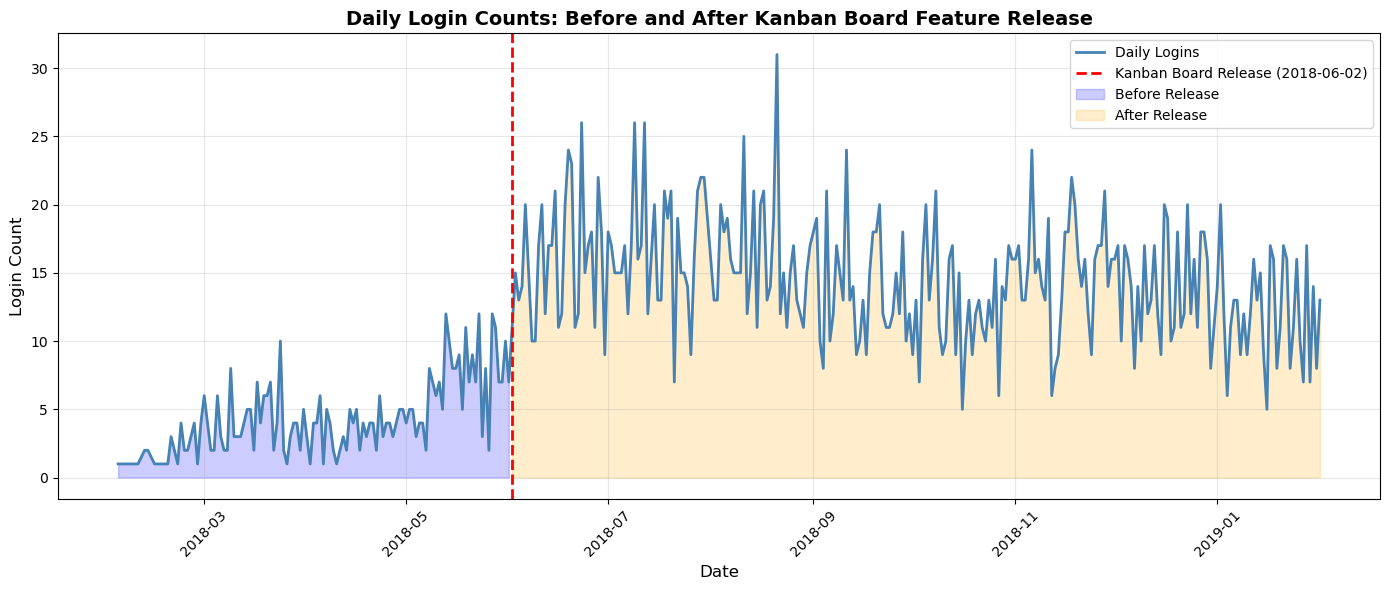


=== Login Statistics ===

Before Feature Release (2018-02-03 00:00:00 to 2018-06-01 00:00:00):
  Average Daily Logins: 4.44
  Total Logins: 488

After Feature Release (2018-06-02 00:00:00 to 2019-02-01 00:00:00):
  Average Daily Logins: 14.58
  Total Logins: 3572


In [5]:
# Visualisation 1: Daily Login Counts with Feature Change Date
feature_release_date = pd.to_datetime('2018-06-02')

plt.figure(figsize=(14, 6))
plt.plot(df_logins['login_date'], df_logins['login_count'], linewidth=2, color='steelblue', label='Daily Logins')

# Add vertical line at feature release date
plt.axvline(x=feature_release_date, color='red', linestyle='--', linewidth=2, label='Kanban Board Release (2018-06-02)')

# Fill areas before and after
before_data = df_logins[df_logins['login_date'] < feature_release_date]
after_data = df_logins[df_logins['login_date'] >= feature_release_date]

if len(before_data) > 0:
    plt.fill_between(before_data['login_date'], before_data['login_count'], alpha=0.2, color='blue', label='Before Release')
if len(after_data) > 0:
    plt.fill_between(after_data['login_date'], after_data['login_count'], alpha=0.2, color='orange', label='After Release')

plt.xlabel('Date', fontsize=12)
plt.ylabel('Login Count', fontsize=12)
plt.title('Daily Login Counts: Before and After Kanban Board Feature Release', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Statistics before and after
print("\n=== Login Statistics ===")
print(f"\nBefore Feature Release ({before_data['login_date'].min()} to {before_data['login_date'].max()}):")
print(f"  Average Daily Logins: {before_data['login_count'].mean():.2f}")
print(f"  Total Logins: {before_data['login_count'].sum()}")

print(f"\nAfter Feature Release ({after_data['login_date'].min()} to {after_data['login_date'].max()}):")
print(f"  Average Daily Logins: {after_data['login_count'].mean():.2f}")
print(f"  Total Logins: {after_data['login_count'].sum()}")

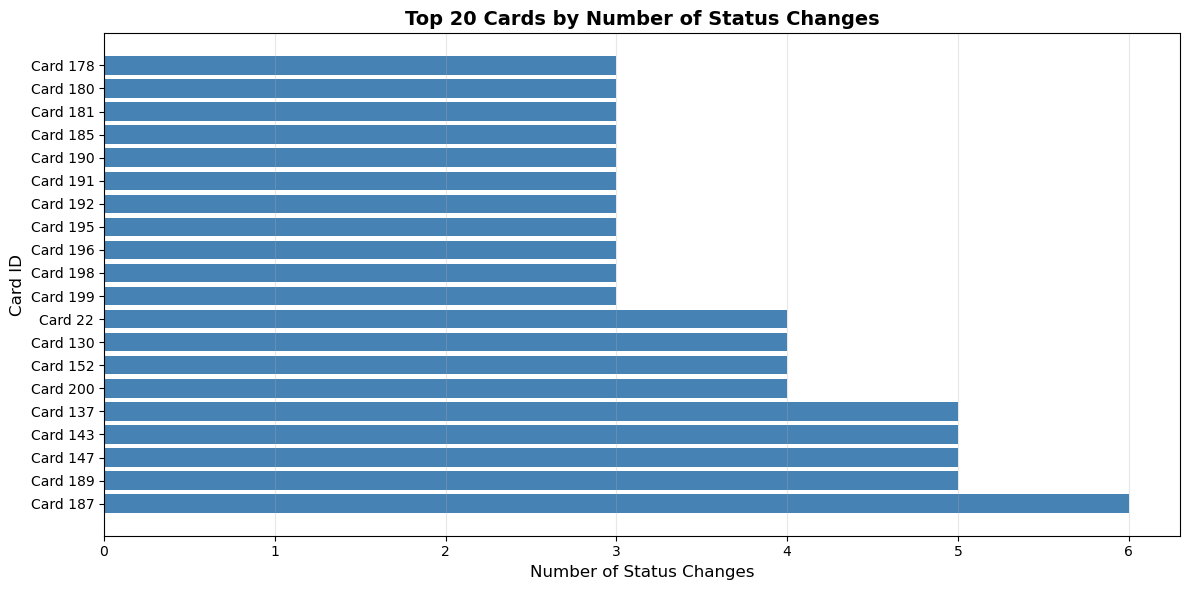


=== Status Changes Summary ===
Total Unique Cards: 200
Average Status Changes per Card: 2.43
Maximum Status Changes: 6 (Card 187)
Minimum Status Changes: 1


In [9]:
# Visualisation 2: Status Changes by Card (Top 20)
top_20_cards = df_status_changes.head(20)

plt.figure(figsize=(12, 6))
plt.barh(range(len(top_20_cards)), top_20_cards['status_changes'], color='steelblue')
plt.yticks(range(len(top_20_cards)), [f"Card {cid}" for cid in top_20_cards['cardID']])
plt.xlabel('Number of Status Changes', fontsize=12)
plt.ylabel('Card ID', fontsize=12)
plt.title('Top 20 Cards by Number of Status Changes', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n=== Status Changes Summary ===")
print(f"Total Unique Cards: {len(df_status_changes)}")
print(f"Average Status Changes per Card: {df_status_changes['status_changes'].mean():.2f}")
print(f"Maximum Status Changes: {df_status_changes['status_changes'].max()} (Card {df_status_changes.loc[df_status_changes['status_changes'].idxmax(), 'cardID']})")
print(f"Minimum Status Changes: {df_status_changes['status_changes'].min()}")

In [ ]:
# Close Database Connection
conn.close()
print("Database connection closed.")

**Idea 1: Notifications for idle cards**
* Hypothesis: Cards that have not been moved for a while may have been forgotten or are taking too long to be finished.
* Expected Impact: Ensures that users are aware of all tasks such as those with lower priority.
* What the feature is: Cards that have surpassed a certain period of being in the backlog or in-progress section create a notification to the users indicating their idle status.

**Idea 2: Archive for completed cards**
* Hypothesis: Over time, the collection of completed cards will accumulate and will be messy to organise/manage if a user has to go back to that category.
* Expected Impact: Will make the swimlane more organised and will not look as messy and mountainous.
* What the feature is: A new swimlane called 'Archive' that holds all completed cards after it has resided in the completed swimlane for a certain period of time. This new swimlane does not need to be part of the kanban board.

**Idea 3: Know what has changed**
* Hypothesis: After a while, the kanban board may have had many changes and it might be difficult to keep track of what moved.
* Expected Impact: Makes organisation of kanban board and cards a lot easier.
* What the feature is: Clicking on a card opens up a pop-up displaying all the changes that card has gone through.